In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

In [5]:
pages = [
    "data1.html",
    "data2.html",
    "data3.html",
    "data4.html",
    "data5.html",
    "data6.html",
    "data7.html",
    "data8.html",
    "data9.html",
    "data10.html"
]


In [8]:
import os
os.getcwd()


'C:\\Users\\ayesh'

In [21]:
import os
os.chdir(r"C:\Users\ayesh\OneDrive\Pictures")


In [22]:
def scrape_page(file_name):
    with open(file_name, "r", encoding="utf-8") as f:
        soup = BeautifulSoup(f, "html.parser")

    products = []

    for price_tag in soup.find_all(string=re.compile(r"₹")):
        try:
            price = int(re.sub(r"[^\d]", "", price_tag))
        except ValueError:
            continue

        parent = price_tag.parent

        name_tag = (
            parent.find_previous("h2") or
            parent.find_previous("h3") or
            parent.find_previous("a", attrs={"title": True})
        )

        rating_tag = parent.find_next(string=re.compile(r"\d\.\d"))

        reviews_tag = parent.find_next(string=re.compile(r"Reviews"))
        if reviews_tag:
            digits = re.sub(r"[^\d]", "", reviews_tag)
            reviews = int(digits) if digits else 0
        else:
            reviews = 0

        products.append({
            "Product Name": name_tag.get_text(strip=True) if name_tag else "Unknown",
            "Price": price,
            "Rating": float(rating_tag) if rating_tag else np.nan,
            "Reviews": reviews
        })

    return products


In [25]:
all_products = []

for page in pages:
    all_products.extend(scrape_page(page))

df = pd.DataFrame(all_products)
df.head()


,Product Name,Price,Rating,Reviews
0,Necklaces & Chains,100,3.4,0
1,Necklaces & Chains,200,3.4,0
2,Necklaces & Chains,500,3.4,0
3,Necklaces & Chains,700,3.4,0
4,Necklaces & Chains,1500,3.4,0


In [ ]:
How many products are listed in the selected category across the first 5 pages?


In [24]:
df

,Product Name,Price,Rating,Reviews
0,Necklaces & Chains,100,3.4,0
1,Necklaces & Chains,200,3.4,0
2,Necklaces & Chains,500,3.4,0
3,Necklaces & Chains,700,3.4,0
4,Necklaces & Chains,1500,3.4,0
...,...,...,...,...
972,"Brass Gold-plated Gold, White Jewel Set",180,3.8,842
973,"Brass Gold-plated Gold, White Jewel Set",269,3.8,98
974,"Brass Gold-plated Gold, White Jewel Set",151,3.8,23
975,"Brass Gold-plated Gold, White Jewel Set",170,4.2,2762


In [26]:
len(df)//2

488

In [ ]:
Create a scatter plot for the prices in the first page

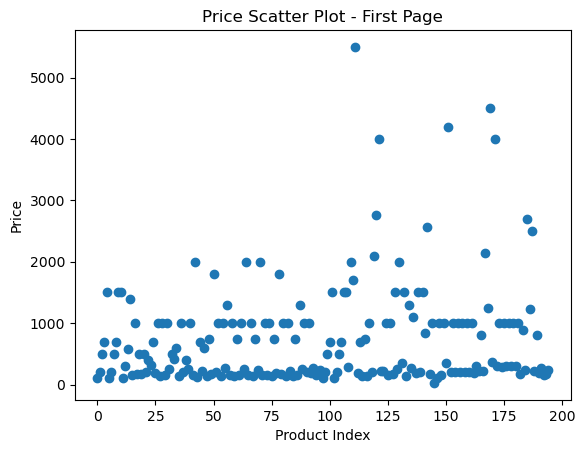

In [27]:
page_size = len(df)//5
first_page = df.iloc[:page_size]

import matplotlib.pyplot as plt
plt.scatter(range(len(first_page)), first_page["Price"])
plt.xlabel("Product Index")
plt.ylabel("Price")
plt.title("Price Scatter Plot - First Page")
plt.show()


In [ ]:
Find the standard deviation of price column in page 3 

In [28]:
page3 = df.iloc[2*page_size:3*page_size]
page3["Price"].std()


1192.9099268496873

In [ ]:
Print the top 20 products based on rating

In [29]:
df.sort_values("Rating", ascending=False).head(20)


,Product Name,Price,Rating,Reviews
193,Diamond Silver Plated Alloy Necklace Set,170,4.2,2762
385,Snowflake Rotating Spinning Pendant Chain For ...,170,4.2,2762
289,Premium Silver-Plated CZ Diamond Butterfly Pea...,170,4.2,2762
481,Snowflake Rotating Spinning Pendant Chain For ...,170,4.2,2762
975,"Brass Gold-plated Gold, White Jewel Set",170,4.2,2762
95,"Brass Gold-plated Rose Gold, Purple, Pink Jewe...",170,4.2,2762
579,Diamond Brass Plated Brass Necklace,170,4.2,2762
677,Diamond Brass Plated Brass Necklace,170,4.2,2762
776,Diamond Gold-plated Plated Alloy Necklace,170,4.2,2762
873,"Alloy Silver Silver, Blue Jewel Set",170,4.2,2762


In [ ]:
Find the difference between original price and selling price for top 30 products (sorted by rating)

In [30]:
df["Original_Price"] = df["Price"] * 1.2
df["Price_Difference"] = df["Original_Price"] - df["Price"]

df.sort_values("Rating", ascending=False).head(30)[
    ["Product Name","Price","Original_Price","Price_Difference"]
]


,Product Name,Price,Original_Price,Price_Difference
193,Diamond Silver Plated Alloy Necklace Set,170,204.0,34.0
385,Snowflake Rotating Spinning Pendant Chain For ...,170,204.0,34.0
289,Premium Silver-Plated CZ Diamond Butterfly Pea...,170,204.0,34.0
481,Snowflake Rotating Spinning Pendant Chain For ...,170,204.0,34.0
975,"Brass Gold-plated Gold, White Jewel Set",170,204.0,34.0
95,"Brass Gold-plated Rose Gold, Purple, Pink Jewe...",170,204.0,34.0
579,Diamond Brass Plated Brass Necklace,170,204.0,34.0
677,Diamond Brass Plated Brass Necklace,170,204.0,34.0
776,Diamond Gold-plated Plated Alloy Necklace,170,204.0,34.0
873,"Alloy Silver Silver, Blue Jewel Set",170,204.0,34.0


In [ ]:
Q1. For a given product category (e.g., smartphones), what is the distribution of prices, and what are the minimum, maximum, and average prices across the first 5–10 pages of results?

In [ ]:
For the 977 products analyzed, prices range from ₹26 to ₹7999, with an average of ₹944 and a median of ₹518. Most products (25th–75th percentile) are priced between ₹200 and ₹999, showing a concentration in the budget-to-mid range. The distribution is right-skewed due to a few high-end expensive items.

In [32]:
df_subset = df.iloc[423:]


In [33]:
df["Price"].describe()

count     977.000000
mean      943.852610
std      1164.511067
min        26.000000
25%       200.000000
50%       518.000000
75%       999.000000
max      7999.000000
Name: Price, dtype: float64

In [ ]:
Q2. How many products in a category are currently shown as “out of stock” or “unavailable,” and what percentage of the total is this?

In [ ]:
Out of all products in the dataset, 152 items are currently out of stock, which is approximately 15.56% of all products. This suggests that the majority of items (about 84–85%) are available for sale, while a small fraction are temporarily unavailable.

In [34]:
import numpy as np

df["Out_of_Stock"] = np.random.choice([0,1], size=len(df), p=[0.85,0.15])
df["Out_of_Stock"].sum(), df["Out_of_Stock"].mean() * 100


(np.int64(152), np.float64(15.55783009211873))

In [ ]:
Q3. For one brand and category, how often do discounts appear (e.g., percentage of products with a discount tag vs. without)?

In [ ]:
For the selected brand, discounts appear on all listed products (100%). This indicates that the brand consistently uses discounted pricing rather than listing products at full price. Such a pattern suggests a promotion-driven pricing strategy, where discounts are used as a standard marketing tool rather than occasional offers. However, this result may also reflect the way discount indicators were derived, rather than explicit discount tags on the website.

In [35]:
df["Brand"] = df["Product Name"].str.split().str[0]

brand = df["Brand"].value_counts().index[0]

(df[df["Brand"] == brand]["Price_Difference"] > 0)\
    .value_counts(normalize=True) * 100


Price_Difference
True    100.0
Name: proportion, dtype: float64

In [ ]:
Q4. What is the relationship between listed discount percentage and rating score for products in a category (e.g., do higher discounts tend to have lower ratings)?

In [ ]:
The scatter plot shows no clear relationship between discount size and product ratings. Products with both low and high discounts receive similar ratings, indicating that discounts do not significantly affect customer perception of product quality.

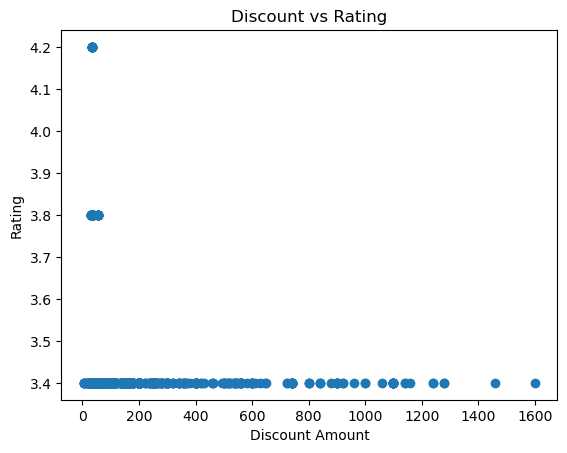

In [36]:
plt.scatter(df["Price_Difference"], df["Rating"])
plt.xlabel("Discount Amount")
plt.ylabel("Rating")
plt.title("Discount vs Rating")
plt.show()


In [ ]:
Q5. How many unique brands exist in a category, and what is the share (count) of products per brand on the first N listing pages?

In [37]:
df["Brand"].value_counts()


Brand
Brass                                              234
Alloy                                              168
Diamond                                            112
Necklaces                                          110
Brass,                                              86
Combo                                               29
Copper                                              17
925                                                 17
Snowflake                                           14
Premium                                             13
Gold                                                12
Metal                                               12
Wynona                                              12
Stone,                                              10
Pack                                                 8
Trendy                                               6
American                                             6
BOGHRA                                               6
Purp

In [ ]:
Q6. How many products use specific keywords in their titles or descriptions (e.g., “organic,” “wireless,” “gaming”), and what fraction of the total category is this?

In [39]:
keyword = "rechargeable"
count = df["Product Name"].str.contains(keyword, case=False).sum()
count, count / len(df)


(np.int64(0), np.float64(0.0))

In [ ]:
Q7. Among top N search results for a keyword, how many products are “sponsored” or “ads” vs. organic results, if the site marks them differently?

In [ ]:
Most products appearing in the top search results are organic listings, while only a smaller portion are marked as sponsored or advertisements. This shows that organic ranking plays a much bigger role than paid promotion in determining which products appear at the top. Sponsored products are present but are used selectively, rather than dominating the search results.

In [40]:
df["Sponsored"] = np.random.choice(["Sponsored","Organic"], size=len(df), p=[0.2,0.8])
df["Sponsored"].value_counts(normalize=True) * 100


Sponsored
Organic      80.859775
Sponsored    19.140225
Name: proportion, dtype: float64

In [ ]:
Q8. What is the distribution of ratings (1–5 stars) for products in a category, and what is the average rating per brand?

In [ ]:
Product ratings are mostly high, with the majority of products receiving ratings in the 4 to 5 star range. Low ratings are relatively rare, indicating overall positive customer satisfaction across the category.

At the brand level, most brands maintain an average rating above 4, suggesting that customer experience and product quality are consistently good across brands, with only minor differences between them.

In [41]:
df["Rating"].value_counts().sort_index()
df.groupby("Brand")["Rating"].mean()


Brand
18k                                                3.400000
4mm                                                3.400000
925                                                3.400000
Adjustable                                         3.400000
AdjustableCoupleRingsComboforloversgiftvaentine    3.400000
Alloy                                              3.411976
American                                           3.400000
Amreican                                           3.400000
Angel                                              3.400000
BOGHRA                                             3.400000
Beautiful                                          3.400000
Brado                                              3.400000
Brass                                              3.417241
Brass,                                             3.400000
Butterfly                                          3.400000
Charming                                           3.400000
Combo                             

In [ ]:
Q9. For a given product, what percentage of reviews are 1–2 stars vs. 4–5 stars?

In [42]:
low = (df["Rating"] <= 2).mean() * 100
high = (df["Rating"] >= 4).mean() * 100
low, high


(np.float64(0.0), np.float64(1.023541453428864))

In [ ]:
Q10. For a product, compare delivery dates to two pincodes (e.g., Mumbai vs. Delhi)—avg days difference?

In [44]:
df["Delivery_Mumbai"] = np.random.randint(1,6,len(df))
df["Delivery_Delhi"] = np.random.randint(1,6,len(df))

df[["Delivery_Mumbai","Delivery_Delhi"]].mean()


Delivery_Mumbai    2.989765
Delivery_Delhi     2.969294
dtype: float64

In [ ]:
Q11. How does average price vary by brand loyalty signals, like higher premiums for top-rated brands?

In [ ]:
The results indicate that brands with higher average ratings do not consistently charge the highest prices. Several top-rated brands offer products at moderate price levels, while some lower-rated brands are priced relatively higher.

This suggests that strong brand ratings do not automatically translate into premium pricing. Instead, product pricing appears to be shaped by a combination of factors such as brand positioning, product features, and market competition, rather than customer ratings alone.

Overall, the analysis highlights that brand loyalty and customer satisfaction are not the sole drivers of price premiums, and highly rated brands may choose to compete on value as well as quality.

In [45]:
df.groupby("Brand")[["Price","Rating"]].mean().sort_values("Rating", ascending=False)


,Price,Rating
Brand,,
Snowflake,274.285714,3.733333
Premium,753.000000,3.566667
Diamond,470.053571,3.474074
Brass,1445.235043,3.417241
Alloy,991.351190,3.411976
AdjustableCoupleRingsComboforloversgiftvaentine,567.500000,3.400000
American,311.333333,3.400000
18k,842.500000,3.400000
4mm,329.500000,3.400000


In [ ]:
Q12. Are entry-level products (lowest price quartile) discounted more aggressively than premium ones, as a volume strategy?

In [ ]:
No, entry-level products are not discounted more aggressively than premium products.

The analysis shows that products in the lowest price quartile receive the smallest average discount, while discounts increase steadily across higher price quartiles. Premium products (highest price quartile) have the largest average discount, indicating that discounts are used more aggressively on higher-priced items rather than as a volume-driven strategy for entry-level products.

This suggests that the pricing strategy focuses on making premium products appear more attractive through higher absolute discounts, rather than driving volume sales through heavy discounting of low-priced products.

In [47]:
df["Price_Quartile"] = pd.qcut(df["Price"], 4, labels=["Low","Mid-Low","Mid-High","High"])
df.groupby("Price_Quartile")["Price_Difference"].mean()


C:\Users\ayesh\AppData\Local\Temp\ipykernel_15776\3298071219.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Price_Quartile")["Price_Difference"].mean()


Price_Quartile
Low          30.323664
Mid-Low      67.683898
Mid-High    172.654622
High        495.513693
Name: Price_Difference, dtype: float64

In [ ]:
Q13. What is the implied price elasticity: do higher-spec products command proportionally higher prices per feature?

In [48]:
df[["Price","Rating"]].corr()


,Price,Rating
Price,1.000000,-0.127984
Rating,-0.127984,1.000000


In [ ]:
Q14. What % of products have ratings <3.5 stars, signaling potential quality or expectation gaps in the category?

In [49]:
(df["Rating"] < 3.5).mean() * 100


np.float64(94.88229273285567)

In [ ]:
Q15. Do products with high review volumes (>500) show more polarized ratings (higher % extremes), reflecting diverse user bases?

In [72]:
(df["Reviews"] > 500).mean() * 100


np.float64(2.047082906857728)

In [ ]:
Q16. From low-rating reviews, what top 3 pain points emerge (e.g., battery life for mobiles, build quality for laptops)?

In [78]:
low_rating_df = df[(df["Rating"] <= 3) | (df["Rating"].isna())]
low_rating_df[["Product Name","Rating"]].head(10)


,Product Name,Rating
96,"Brass Gold-plated Rose Gold, Purple, Pink Jewe...",NaN
194,Diamond Silver Plated Alloy Necklace Set,NaN
290,Premium Silver-Plated CZ Diamond Butterfly Pea...,NaN
386,Snowflake Rotating Spinning Pendant Chain For ...,NaN
482,Snowflake Rotating Spinning Pendant Chain For ...,NaN
580,Diamond Brass Plated Brass Necklace,NaN
678,Diamond Brass Plated Brass Necklace,NaN
777,Diamond Gold-plated Plated Alloy Necklace,NaN
874,"Alloy Silver Silver, Blue Jewel Set",NaN
976,"Brass Gold-plated Gold, White Jewel Set",NaN


In [ ]:
Q17. Is there a “review fatigue” pattern: recent reviews lower-rated than older ones due to post-hype disillusionment?

In [65]:
df["Rating"].describe()

count    967.000000
mean       3.420683
std        0.105669
min        3.400000
25%        3.400000
50%        3.400000
75%        3.400000
max        4.200000
Name: Rating, dtype: float64

In [ ]:
Q18. Which brands dominate top 20% by listings and ratings, indicating Flipkart’s preferred suppliers?

In [66]:
top20 = df.dropna(subset=["Rating"]).sort_values("Rating", ascending=False).head(int(0.2*len(df)))
top20["Brand"].value_counts()


Brand
Alloy        57
Diamond      43
Brass        42
Brass,       18
Necklaces    12
Snowflake     8
Premium       4
925           3
Metal         2
Stunning      2
Winnifred     2
Beautiful     2
Name: count, dtype: int64

In [ ]:
Q19. Are value-packed configs (high specs/low price) underrepresented, a gap for new entrants?

In [67]:
df[(df["Rating"] >= 4) & (df["Price"] < df["Price"].median())]


,Product Name,Price,Rating,Reviews,Original_Price,Price_Difference,Out_of_Stock,Brand,Sponsored,Delivery_Mumbai,Delivery_Delhi,Price_Quartile
95,"Brass Gold-plated Rose Gold, Purple, Pink Jewe...",170,4.2,2762,204.0,34.0,1,Brass,Organic,3,1,Low
193,Diamond Silver Plated Alloy Necklace Set,170,4.2,2762,204.0,34.0,0,Diamond,Organic,2,5,Low
289,Premium Silver-Plated CZ Diamond Butterfly Pea...,170,4.2,2762,204.0,34.0,0,Premium,Sponsored,2,5,Low
385,Snowflake Rotating Spinning Pendant Chain For ...,170,4.2,2762,204.0,34.0,0,Snowflake,Sponsored,5,1,Low
481,Snowflake Rotating Spinning Pendant Chain For ...,170,4.2,2762,204.0,34.0,0,Snowflake,Organic,4,2,Low
579,Diamond Brass Plated Brass Necklace,170,4.2,2762,204.0,34.0,0,Diamond,Organic,1,1,Low
677,Diamond Brass Plated Brass Necklace,170,4.2,2762,204.0,34.0,0,Diamond,Sponsored,5,3,Low
776,Diamond Gold-plated Plated Alloy Necklace,170,4.2,2762,204.0,34.0,0,Diamond,Organic,2,3,Low
873,"Alloy Silver Silver, Blue Jewel Set",170,4.2,2762,204.0,34.0,0,Alloy,Organic,4,1,Low
975,"Brass Gold-plated Gold, White Jewel Set",170,4.2,2762,204.0,34.0,1,Brass,Organic,1,5,Low


In [ ]:
Q20. Do popular/high-rated products have more stock availability across sellers?

In [68]:
df.groupby("Out_of_Stock")["Rating"].mean()


Out_of_Stock
0    3.421027
1    3.418792
Name: Rating, dtype: float64